## Asignatura: Seminario Avanzado de Aprendizaje Automático 2025-2026
## **Entregable Parte 3**
#### Master en Lógica, Computación e Inteligencia Artificial
#### Profesor: Eduardo Sánchez Karhunen (fesanchez at us.es)


#### Nombre del alumno/a:

Jose Sanz

# **Desafío: Tu Primer Clasificador con BERT**

Ahora que ya conoces los fundamentos de los modelos Transformer y las arquitecturas BERT/GPT, ha llegado el momento de aplicar ese conocimiento. Te propongo un reto abierto y creativo. Vamos a hacer algo muy parecido a lo que te podría tocar en tu primer día trabajando en una empresa de IA. Te encargan una tarea sin darte muchas pistas, y tú tienes que organizarte y sacarla adelante. No te preocupes: aquí tendrás más tiempo que en la vida real 😉. En el mundo real te darían una mañana para hacer esto. Aquí vas a tener 10 días. ¡Úsalos bien!

El objetivo no es pasarlo mal, sino que te enfrentes a un reto realista. La idea es que veas la diferencia tan grande que hay entre tener un notebook con el código ya escrito y la infinidad de dificultades que aparecen cuando tienes que montarlo tú mismo desde cero.

**Pista importante:**

La explicación de lo que haces importa casi tanto como lo que haces. En cada paso debes ir explicando:

* Qué pasos has seguido

* Dónde has buscado información

* Qué te ha costado más

* Cómo lo has solucionado

El objetivo es que seas capaz de entrenar y evaluar el modelo. Pero tanto si lo consigues como si no, en el entregable explicalo TODO (incluido los motivos por los que no has sido capaz de completarlo, las dificultades que te has encontrado, etc.).

Pero recuerda que lo más importante es lo que te lleves en tu "mochila" trabajando el notebook y eso es lo que se va a evaluar. Todo eso queda plasmado en la mítica escena de Star Wars donde el Maestro Yoda le dice a SkyWalker: **"El fracaso, el mejor maestro es"**.  

**¿Qué tienes que hacer?**

Escoge **el dataset que quieras** (siempre que sea de procesamiento del lenguaje natural) y **resuelve un problema de clasificación** con él (por ejemplo, clasificar opiniones, intenciones, temas, etc.)

Pero hay una condición:

**Tienes que usar embeddings generados por un modelo tipo BERT.**

Además no vale solo que funcione:

**Tienes que justificar las decisiones** que tomes. Piensa como si tuvieras que explicarle tu solución a tu jefe o a tu cliente.

## 🧪 **Tarea 1: ¡Tu eliges la aventura!**

Es el momento de ponerte en el lugar de un data scientist de verdad. Elige el dataset que más te guste y plantea un problema de clasificación con el.

Para ello, describe:

* Cual es el problema de clasificación que vas a resolver.

     *Tu explicación aquí*

* Qué dataset has elegido y por qué.

     *Tu explicación aquí*

#### Mi respuesta a la Tarea 1

**Qué problema de clasificación voy a resolver**

He decidido montar un clasificador de emociones a partir de texto. La idea, contada de forma sencilla, es: dado un mensaje corto escrito por una persona (por ejemplo un tuit), quiero que el modelo diga qué emoción principal expresa. Es un problema de clasificación multiclase con 6 categorías posibles: alegría (joy), tristeza (sadness), ira (anger), miedo (fear), amor (love) y sorpresa (surprise).

Me parece un problema realista y con sentido: algo parecido se usa para analizar opiniones en redes sociales, medir cómo reacciona la gente ante una noticia o un producto, o para ordenar mensajes de atención al cliente según el tono. Además, al tener 6 clases y no un simple positivo/negativo, da más juego después para analizar dónde acierta y dónde falla el modelo.

**Qué dataset he elegido y por qué**

He elegido el dataset `emotion` (en Hugging Face aparece como `dair-ai/emotion`). Llegué a él buscando datasets de clasificación de texto en el Hub de Hugging Face (https://huggingface.co/datasets), que fue lo primero que miré porque estos datasets se integran muy fácil con la librería `datasets` y con los modelos tipo BERT que vimos en clase.

Razones por las que me encaja bien:

- Es un problema de NLP de clasificación, que es justo lo que pide el enunciado.
- Ya viene dividido en train, validación y test. Esto me viene de cara para la Tarea 3, donde se dice que si el dataset ya trae su propia división, hay que usarla.
- Los textos son cortos (mensajes tipo tuit). Esto es importante porque voy a trabajar en mi portátil con CPU: cuanto más cortos los textos, más rápido los tokeniza y procesa BERT, y menos me afecta tener que recortar frases largas.
- Está en inglés, así que puedo usar `bert-base-uncased`, que es el mismo modelo que usamos en la práctica de clase (Session 1). Prefiero apoyarme en algo que ya entiendo antes que meterme con un modelo nuevo.
- Tiene las clases desbalanceadas y algunas emociones que se parecen entre sí (por ejemplo alegría y amor, o miedo y sorpresa). Esto, que en principio puede sonar a inconveniente, en realidad me viene muy bien para las Tareas 2 y 6: podré comentar el desbalanceo y mirar en la matriz de confusión qué emociones acaba confundiendo el modelo.

**Otras opciones que valoré antes de decidirme**

- AG News (clasificar noticias en 4 temas: mundo, deportes, negocios y ciencia/tecnología): es muy limpio y está balanceado, pero me parecía menos interesante para analizar errores, porque los temas se distinguen bastante bien y casi no se confunden.
- Un dataset en español con un BERT en español (BETO): era la opción que más me apetecía por estar en mi idioma, pero suponía cambiar de modelo respecto a la práctica y, según el dataset, complicarme más el montaje. Lo dejo anotado como una posible mejora para más adelante; primero quiero tener todo el pipeline funcionando de principio a fin.

Al final me quedé con `emotion` porque es el equilibrio que buscaba: un problema realista, manejable en CPU y con suficiente riqueza para poder explicar bien los resultados.

## 🕵️‍♂️ **Tarea 2: Conociendo tus datos**

Antes de hacer magia con BERT, ¡hay que conocer los datos! Haz un pequeño análisis exploratorio: cuántos ejemplos hay, cómo están distribuidas las clases, qué pinta tienen los textos ...

***Tip***: No hace falta que sea un extremadamente técnico, pero intenta entender qué tienes delante.

In [1]:
# Tu código y explicación aquí

#### Mi enfoque para la Tarea 2

Antes de tocar BERT quiero entender bien qué datos tengo entre manos. Me voy a fijar en cuatro cosas sencillas pero importantes:

1. Cuántos ejemplos hay en cada partición (train, validación y test).
2. Cómo están repartidas las 6 clases, para ver si el dataset está equilibrado o no.
3. Qué longitud tienen los textos (en palabras), porque eso me ayudará luego a elegir el `max_length` cuando tokenice.
4. Qué pinta tienen algunos textos de verdad, leyendo ejemplos de cada emoción.

Cargo los datos con la librería `datasets` de Hugging Face, que se encarga de descargar el dataset y dejarlo listo para usar. Para esta parte todavía no necesito TensorFlow: solo quiero mirar los datos.

In [2]:
# Configuracion para que la salida quede limpia (silenciar avisos no criticos).
import os
import warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"   # aviso de symlinks en Windows
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"               # menos mensajes de TensorFlow
warnings.filterwarnings("ignore")

# Librerias para explorar los datos (todavia no hace falta TensorFlow).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Fijo una semilla para que los resultados sean reproducibles.
SEMILLA = 42
np.random.seed(SEMILLA)

# Cargo el dataset 'emotion'. Pruebo varias formas por si cambia el identificador o la config.
dataset = None
for argumentos in [("dair-ai/emotion",), ("dair-ai/emotion", "split"), ("emotion",)]:
    try:
        dataset = load_dataset(*argumentos)
        print("Dataset cargado con:", argumentos)
        break
    except Exception as e:
        print("No se pudo cargar con", argumentos, "->", repr(e)[:120])

# Nombres de las clases (en el mismo orden que los indices 0..5).
nombres_clases = dataset["train"].features["label"].names

print()
print("Particiones y numero de ejemplos:")
for particion, datos in dataset.items():
    print(f"  {particion:12s}: {len(datos)} ejemplos")

print()
print("Clases (indice -> nombre):")
for i, nombre in enumerate(nombres_clases):
    print(f"  {i} -> {nombre}")

# Paso cada particion a un DataFrame de pandas, que para explorar es mas comodo.
df_train = dataset["train"].to_pandas()
df_val = dataset["validation"].to_pandas()
df_test = dataset["test"].to_pandas()

# Anado una columna con el nombre de la emocion (ademas del indice) para que se lea mejor.
for df in (df_train, df_val, df_test):
    df["emocion"] = df["label"].map(lambda i: nombres_clases[i])

print()
print("Primeras filas del train:")
df_train.head()

Dataset cargado con: ('dair-ai/emotion',)

Particiones y numero de ejemplos:
  train       : 16000 ejemplos
  validation  : 2000 ejemplos
  test        : 2000 ejemplos

Clases (indice -> nombre):
  0 -> sadness
  1 -> joy
  2 -> love
  3 -> anger
  4 -> fear
  5 -> surprise

Primeras filas del train:


,text,label,emocion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Lo primero que miro es **cómo están repartidas las clases** en el conjunto de train. Esto es importante porque si una emoción tiene muchísimos más ejemplos que otra (dataset desbalanceado), el modelo tenderá a predecir las clases mayoritarias y le costará las raras. Saberlo ahora me sirve para luego interpretar bien los resultados.

Distribucion de clases en train:
  joy       :  5362  (33.5 %)
  sadness   :  4666  (29.2 %)
  anger     :  2159  (13.5 %)
  fear      :  1937  (12.1 %)
  love      :  1304  (8.2 %)
  surprise  :   572  (3.6 %)


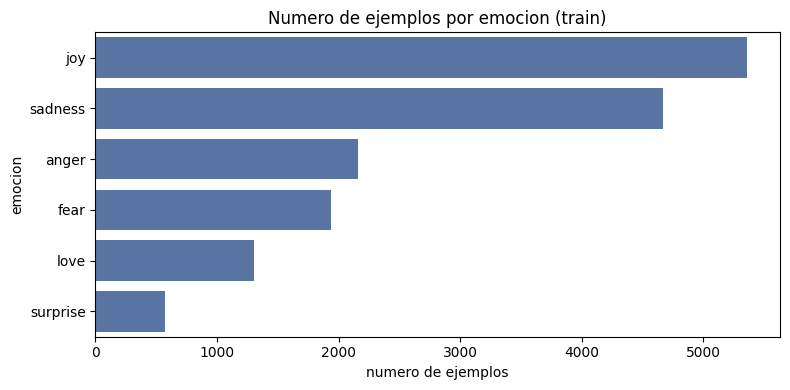

In [3]:
# Cuento cuantos ejemplos hay de cada emocion en train y lo paso a porcentaje.
conteo = df_train["emocion"].value_counts()
porcentaje = (conteo / len(df_train) * 100).round(1)

print("Distribucion de clases en train:")
for emocion in conteo.index:
    print(f"  {emocion:10s}: {conteo[emocion]:5d}  ({porcentaje[emocion]} %)")

# Lo dibujo en un grafico de barras para verlo de un vistazo.
plt.figure(figsize=(8, 4))
sns.barplot(x=conteo.values, y=conteo.index, color="#4C72B0")
plt.title("Numero de ejemplos por emocion (train)")
plt.xlabel("numero de ejemplos")
plt.ylabel("emocion")
plt.tight_layout()
plt.show()

Ahora miro la **longitud de los textos**, contando palabras (separando por espacios). Es una aproximación: BERT no trabaja con palabras sino con *tokens* de WordPiece, que parten algunas palabras en trozos, así que el número real de tokens será algo mayor. Pero para hacerme una idea del tamaño me vale, y me ayudará a decidir el `max_length` en la Tarea 4 (un valor que cubra casi todos los textos sin desperdiciar memoria).

Estadisticas de longitud (en palabras) en train:
count    16000.0
mean        19.2
std         11.0
min          2.0
25%         11.0
50%         17.0
75%         25.0
max         66.0
Name: n_palabras, dtype: float64

Percentil 95: 41 palabras
Percentil 99: 52 palabras
Maximo: 66 palabras


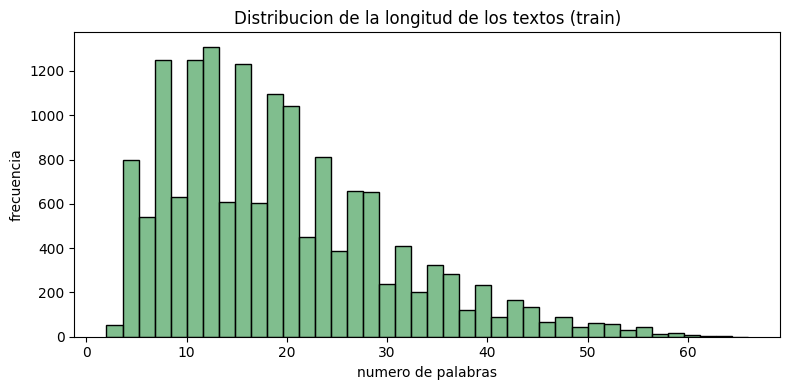

In [4]:
# Longitud de cada texto en numero de palabras.
df_train["n_palabras"] = df_train["text"].str.split().str.len()

print("Estadisticas de longitud (en palabras) en train:")
print(df_train["n_palabras"].describe().round(1))
print()
print("Percentil 95:", int(np.percentile(df_train["n_palabras"], 95)), "palabras")
print("Percentil 99:", int(np.percentile(df_train["n_palabras"], 99)), "palabras")
print("Maximo:", int(df_train["n_palabras"].max()), "palabras")

plt.figure(figsize=(8, 4))
sns.histplot(df_train["n_palabras"], bins=40, color="#55A868")
plt.title("Distribucion de la longitud de los textos (train)")
plt.xlabel("numero de palabras")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()

Por último, leo **algunos ejemplos reales de cada emoción**. Mirar los textos de verdad ayuda a entender el problema: ver si son frases en primera persona, si el vocabulario delata la emoción, y si hay casos que a mí mismo me costaría clasificar (lo que adelanta que al modelo también le costarán).

In [5]:
# Muestro 2 ejemplos de cada emocion para ver que pinta tienen los textos.
for emocion in nombres_clases:
    ejemplos = df_train[df_train["emocion"] == emocion]["text"].head(2).tolist()
    print(f"--- {emocion} ---")
    for t in ejemplos:
        print("  ", t)
    print()

--- sadness ---
   i didnt feel humiliated
   i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

--- joy ---
   i have been with petronas for years i feel that petronas has performed well and made a huge profit
   i do feel that running is a divine experience and that i can expect to have some type of spiritual encounter

--- love ---
   i am ever feeling nostalgic about the fireplace i will know that it is still on the property
   i feel romantic too

--- anger ---
   im grabbing a minute to post i feel greedy wrong
   i am feeling grouchy

--- fear ---
   i feel as confused about life as a teenager or as jaded as a year old man
   i now feel compromised and skeptical of the value of every unit of work i put in

--- surprise ---
   ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
   i have seen heard and read over the past couple of days i am left feelin

#### Qué he aprendido mirando los datos

Después de explorar un poco, estas son mis conclusiones:

**Tamaño y división.** El dataset trae 16000 ejemplos para entrenar, 2000 para validación y 2000 para test. Como ya viene dividido, en la Tarea 3 usaré esta misma división en lugar de inventarme yo el reparto.

**Las clases están muy desbalanceadas.** No todas las emociones aparecen igual de veces:

- joy (alegría): 33,5 %
- sadness (tristeza): 29,2 %
- anger (ira): 13,5 %
- fear (miedo): 12,1 %
- love (amor): 8,2 %
- surprise (sorpresa): 3,6 %

Entre alegría y tristeza se llevan más del 60 % de los ejemplos, mientras que sorpresa apenas tiene un 3,6 %. Esto conviene tenerlo presente: si luego el modelo acierta mucho de media pero falla en sorpresa, será bastante normal, porque ha visto poquísimos ejemplos de esa clase. Por eso en la evaluación (Tarea 6) no me fijaré solo en el accuracy global, sino también en las métricas por clase y en la matriz de confusión. Además me sirve de referencia que un modelo "tonto" que prediga siempre la clase mayoritaria (joy) ya acertaría un 33,5 %, así que el mío tiene que superar claramente ese listón para que valga la pena.

**Los textos son cortos.** En palabras: de media 19, la mitad tienen 17 o menos, el percentil 95 está en 41 y el más largo tiene 66. Esto me viene muy bien para trabajar en CPU. Como BERT no parte por palabras sino en tokens de WordPiece (que suelen salir algunos más que las palabras), el número real de tokens será un poco mayor, pero aun así con un max_length de unos 64 tokens cubriría casi todos los textos sin cortar casi nada. Lo afinaré en la Tarea 4, pero ya tengo una buena referencia.

**Qué pinta tienen.** Casi todos los textos son frases en primera persona que incluyen la palabra "feel" ("i feel...", "i am feeling..."). Tiene sentido, porque el dataset se construyó a partir de mensajes donde la gente cuenta cómo se siente. Leyendo los ejemplos, algunos se entienden enseguida (por ejemplo "i feel romantic too" para love), pero otros son ambiguos incluso para mí (los de surprise no me parecen nada claros). Eso ya me avisa de que habrá clases que al modelo le van a costar más, sobre todo las que tienen pocos ejemplos y se solapan con otras.

## ✂️ **Tarea 3: ¡Divide y vencerás!**

Separa los datos en train y test. Por ahora, olvídate de tensores y frameworks raros: con `numpy` vas más rápido y te evitas líos.

* ¿El dataset ya venía dividido? Usa esa división.
* En caso contrario, usa un 80% para train y un 20% para test.

Quieres que las **clases estén bien representadas** en ambos conjuntos, así que utiliza el argumento `stratify = y` de scikit-learn.

In [6]:
# Tu código y explicación aquí

## 🧱 **Tarea 4: Es hora de construir tu propio Transformer**

Debes crear tu propio modelo basado en BERT. No tienes que inventar la rueda. Vamos a combinar 3 bloques:
  * `BertTokenizer.from_pretrained(...)`
  * `TFBertModel.from_pretrained(...)`
  * Una **cabeza de clasificación** encima.

**Tips**:  
  - Tendrás que tomar decisiones sobre la longitud máxima de las secuencias.   
  - Tienes que tokenizar los textos usando usando padding y truncado.  
  - `TFBertModel` no predice clases por sí mismo. Te da los emebeddings, y tú decides que hacer con ellos.  
  - Usaremos el embedding del token `[CLS]` como resumen de toda la frase.  
  - El encadenamiento de los tres bloques puedes realizarlo con la API funcional de Tensorflow.

In [7]:
# Tu código y explicación aquí

## 🏋️‍♀️ **Tarea 5: Entrenamiento**

¡Llegó la hora de poner a sudar a tu modelo!
Aquí empieza el verdadero drama del Deep Learning: decidir cuántas muestras va a ver de golpe `batch_size`, con qué rapidez va a aprender `learning_rate`, y cuándo parar para no liarla `early_stopping`.

En esta sección tienes que:

* Elegir bien los hiperparámetros.
    - Sí, vas a tener que probar.
    - Y sí, probablemente al principio no funcione tan bien como esperabas.

* Controlar el sobreajuste. Si ves que tu modelo acierta todo en entrenamiento pero falla en validación... mal asunto. Prueba a:

    - Usar Dropout

    - Subir el batch_size

    - Afinar el learning_rate

In [8]:
# Tu código y explicación aquí

## 🧐 Tarea 6: Evaluación

Momento de la verdad!
Tu modelo ha entrenado, ha aprendido (esperemos), y ahora toca ver cómo se comporta con datos que no ha visto nunca.

En esta parte:

* Evalúa el modelo sobre el conjunto de test.

* Representa las curvas de entrenamiento y validación (accuracy y loss) para ver si ha habido sobreajuste, infrajuste… o magia pura.

* Comenta brevemente los resultados: ¿ha aprendido bien? ¿hay alguna clase que le cueste más?

In [9]:
# Tu código y explicación aquí

## ✨ Tarea 7: Reflexión final

* Si has llegado hasta aquí: Enhorabuena!!!. Recuerda explicar todo lo que ha ido pasando por el camino.  

* Si no, describe en detalle hasta donde has llegado y qué está haciendo que no hayas conseguido completar el entregable. Y sobretodo ...., cómo lo vas a arreglar para que cuando te encarguen una tarea real se este tipo, la superes con éxito.

In [10]:
# Tu explicación aquí